In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('../data/raw/stock_data.csv')
df.head()

,date,open,high,low,close,volume,symbol
0,2026-04-10,256.510,262.19,245.70,260.48,191923738,AAPL
1,2026-04-02,250.070,256.18,245.51,255.92,160393105,AAPL
2,2026-03-27,253.970,257.00,248.07,248.80,203871713,AAPL
3,2026-03-20,252.105,255.13,246.00,247.99,223388853,AAPL
4,2026-03-13,255.690,262.48,249.52,250.12,172752233,AAPL


1.date   -> heftenin son is gunu

2.open   -> hemin heftenin ilk is gunu  Acilis qiymeti

3.high   -> hemin hefte en yuksek qiymet

4.low    -> hemin hefte en asagi qiymet

5.close  -> heftenin son is gunu Baglanis qiymeti

6.volume -> hemin heftede alinib satilmis sehmler sayi

7.symbol -> Sirket

In [5]:
df.shape

(6089, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6089 entries, 0 to 6088
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    6089 non-null   object 
 1   open    6089 non-null   float64
 2   high    6089 non-null   float64
 3   low     6089 non-null   float64
 4   close   6089 non-null   float64
 5   volume  6089 non-null   int64  
 6   symbol  6089 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 333.1+ KB


In [7]:
df.describe()

,open,high,low,close,volume
count,6089.000000,6089.000000,6089.000000,6089.000000,6.089000e+03
mean,374.040481,386.661022,362.916911,375.381527,1.299094e+08
std,574.150627,592.553212,558.062952,575.870629,1.404376e+08
min,5.910000,7.660000,5.510000,5.970000,1.294600e+06
25%,54.900000,57.430000,52.530000,55.170000,2.534320e+07
50%,181.860000,187.630000,175.370000,181.990000,8.401009e+07
75%,418.380000,429.370000,404.243400,417.940000,1.892757e+08
max,3744.000000,3773.078200,3570.455000,3719.340000,1.166302e+09


In [8]:
df.isnull().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
symbol    0
dtype: int64

In [10]:
df['symbol'].value_counts()

symbol
AAPL     1379
MSFT     1379
AMZN     1379
GOOGL    1129
TSLA      823
Name: count, dtype: int64

In [11]:
print(df['date'].min())
print(df['date'].max())

1999-11-12
2026-04-10


In [16]:
df.loc[df.groupby('symbol')['close'].idxmax()]

,date,open,high,low,close,volume,symbol
707,2012-09-21,699.350,705.0700,693.620,700.095,71663100,AAPL
4135,2021-07-09,3530.110,3759.9855,3529.000,3719.340,21001690,AMZN
1608,2021-11-19,2978.010,3019.3300,2944.800,2978.530,6566907,GOOGL
2544,2025-08-01,514.080,555.4500,509.435,524.110,137752650,MSFT
5559,2020-08-28,2126.275,2318.4900,1927.520,2213.400,88736115,TSLA


In [15]:
df.loc[df.groupby('symbol')['close'].idxmin()]

,date,open,high,low,close,volume,symbol
1199,2003-04-17,13.710,13.75,12.72,13.12,43560000,AAPL
5167,2001-09-28,7.700,7.83,5.67,5.97,33047100,AMZN
1558,2022-11-04,95.420,96.03,83.34,86.58,248287592,GOOGL
3400,2009-03-06,16.035,16.40,14.87,15.28,412893700,MSFT
6088,2010-07-09,20.000,20.00,14.98,17.40,25550600,TSLA


In [17]:
df[df['volume'] == 0]

,date,open,high,low,close,volume,symbol


In [18]:
df[df['close'] <= 0]

,date,open,high,low,close,volume,symbol


In [21]:
df.duplicated(subset=['date','symbol']).sum()

np.int64(0)

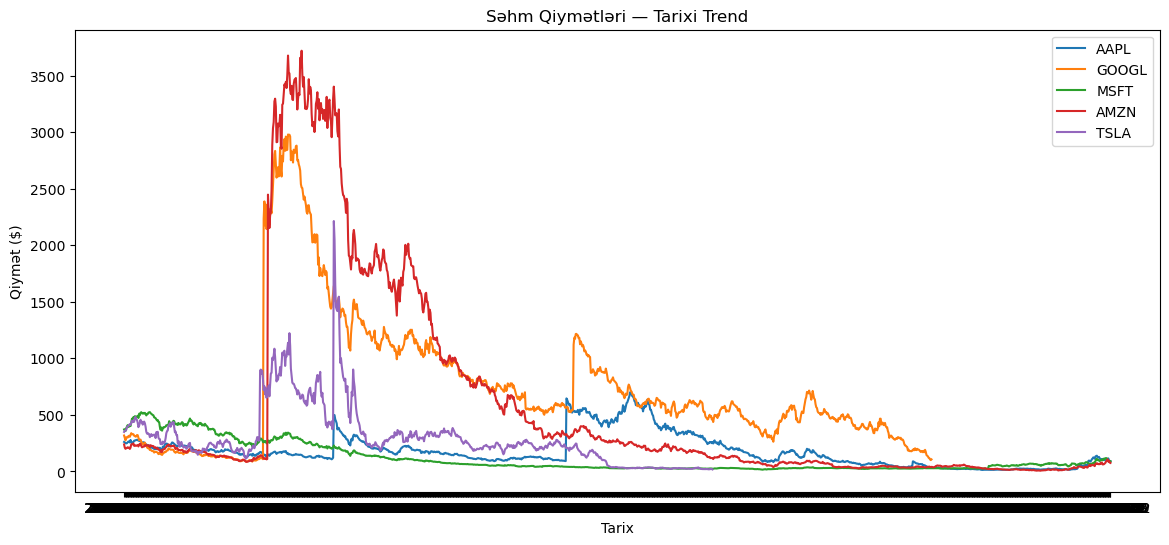

In [22]:
# Hər səhmin qiymət trendi
plt.figure(figsize=(14,6))
for symbol in df['symbol'].unique():
    temp = df[df['symbol'] == symbol]
    plt.plot(temp['date'], temp['close'], label=symbol)
plt.legend()
plt.title('Səhm Qiymətləri — Tarixi Trend')
plt.xlabel('Tarix')
plt.ylabel('Qiymət ($)')
plt.show()

In [23]:
df.to_csv('../data/processed/cleaned_stock_data.csv', index=False)
